In [2]:
!pip install yfinance

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
aapl = yf.download("AAPL", start="2022-01-01", end="2024-01-01")
nvda = yf.download("NVDA", start="2022-01-01", end="2024-01-01")

/tmp/ipykernel_1324/876726386.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download("AAPL", start="2022-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1324/876726386.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda = yf.download("NVDA", start="2022-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [5]:
def calcular_RSI(data, window=14):
    delta = data['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

In [6]:
def calcular_MACD(data):
    ema12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema26 = data['Close'].ewm(span=26, adjust=False).mean()

    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()

    return macd, signal

In [7]:
for df in [aapl, nvda]:
    df['RSI'] = calcular_RSI(df)
    df['MACD'], df['Signal'] = calcular_MACD(df)

In [12]:
def generar_senales(df):
    df['Buy'] = (df['RSI'] < 40) & (df['MACD'] > df['Signal'])
    df['Sell'] = (df['RSI'] > 60) & (df['MACD'] < df['Signal'])
    return df

aapl = generar_senales(aapl)
nvda = generar_senales(nvda)

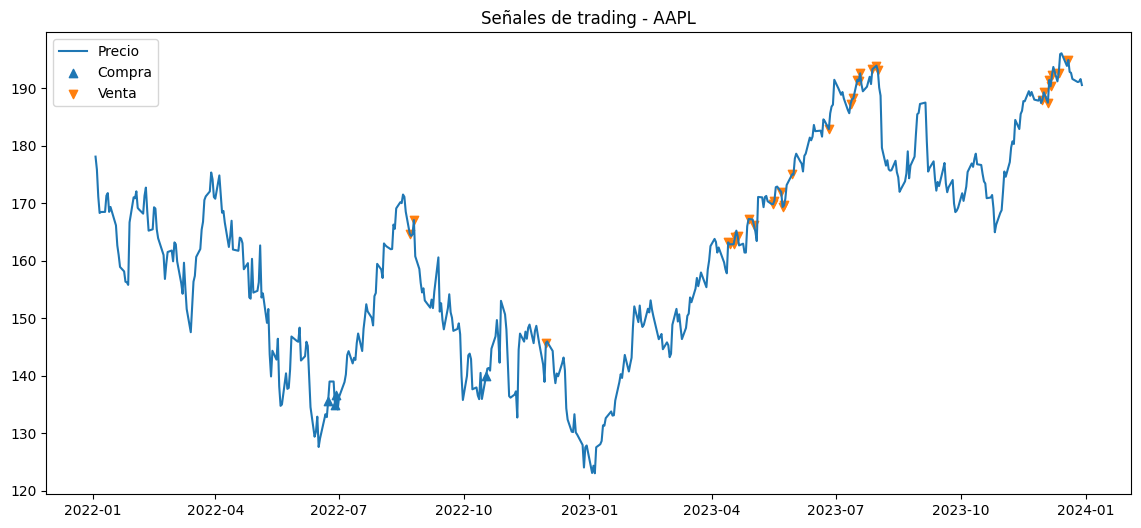

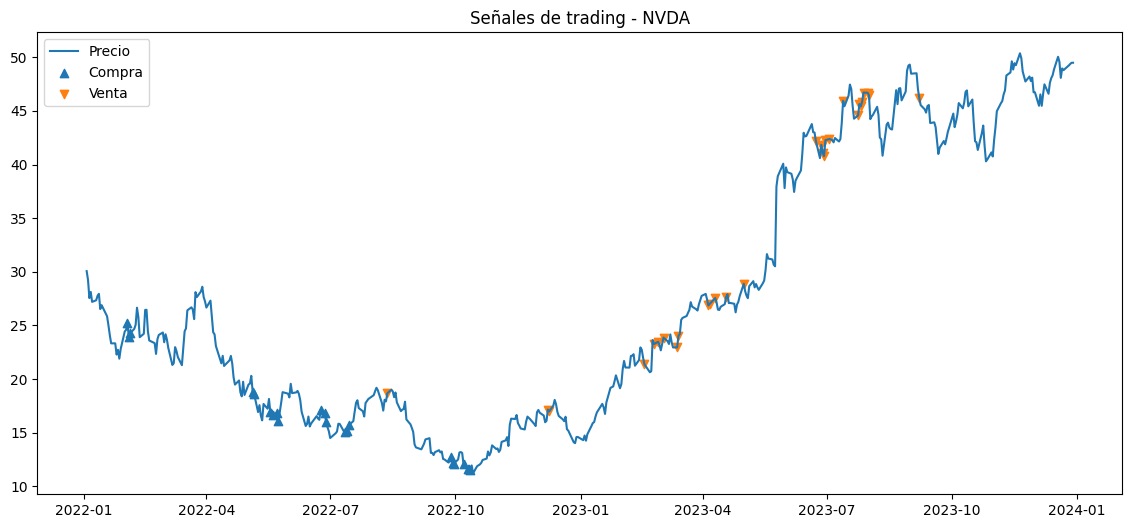

In [13]:
def graficar(df, nombre):
    plt.figure(figsize=(14,6))
    plt.plot(df['Close'], label='Precio')

    plt.scatter(df.index[df['Buy']],
                df['Close'][df['Buy']],
                marker='^', label='Compra')

    plt.scatter(df.index[df['Sell']],
                df['Close'][df['Sell']],
                marker='v', label='Venta')

    plt.title(f'Señales de trading - {nombre}')
    plt.legend()
    plt.show()

graficar(aapl, "AAPL")
graficar(nvda, "NVDA")

Este notebook implementa los indicadores técnicos RSI y MACD para generar señales de compra y venta en acciones.

El RSI identifica condiciones de sobrecompra (>60) y sobreventa (<40), mientras que el MACD detecta cambios de tendencia mediante cruces entre la línea MACD y su señal. Se ajustaron los umbrales del RSI a 40 y 60 para aumentar la sensibilidad del modelo, permitiendo identificar más oportunidades de compra y venta sin perder coherencia con el análisis técnico.

Las señales generadas muestran coherencia con el comportamiento del precio, cumpliendo con los principios del análisis técnico.

Se observa que en ciertas zonas del gráfico, especialmente durante tendencias alcistas fuertes, el modelo genera múltiples señales de venta debido a niveles elevados del RSI.

Esto ocurre porque el RSI identifica condiciones de sobrecompra, pero no necesariamente implica una reversión inmediata del precio, ya que en mercados con tendencia fuerte el precio puede continuar subiendo.

Esto representa una limitación del modelo, ya que no incorpora un filtro de tendencia, lo que podría mejorar la precisión de las señales.

Para mejorar el modelo, se puede incorporar una media móvil como filtro de tendencia. Esto permitiría evitar señales de venta en tendencias alcistas fuertes, donde el RSI puede permanecer en niveles altos por periodos prolongados.

El uso de medias móviles ayuda a distinguir entre condiciones de sobrecompra y una tendencia sólida del mercado, mejorando la precisión del modelo.

Validación del modelo:

Se realizó una validación visual utilizando TradingView para el activo AAPL y NVDA.